In [2]:
# Import packages expected to be used
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.stats.anova import anova_lm
import os
from pathlib import Path

In [3]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                        summarize)
from ISLP import confusion_table
from ISLP.models import contrast
from ISLP.bart import BART

In [4]:
from sklearn.discriminant_analysis import \
                        (LinearDiscriminantAnalysis as LDA,
                        QuadraticDiscriminantAnalysis as QDA)
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error as myMSE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (GradientBoostingRegressor, 
                                BaggingClassifier,
                                RandomForestClassifier)
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# San Francisco Crime Classification competition on Kaggle.com

In [6]:
# Load the dataset
os.chdir("/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 8")
dfTrain = pd.read_csv("crimeTrain.csv") # Training set
dfTest = pd.read_csv("crimeTest.csv") # Test set
# Show imported
dfTrain

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541
...,...,...,...,...,...,...,...,...,...
878044,2003-01-06 00:15:00,ROBBERY,ROBBERY ON THE STREET WITH A GUN,Monday,TARAVAL,NONE,FARALLONES ST / CAPITOL AV,-122.459033,37.714056
878045,2003-01-06 00:01:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Monday,INGLESIDE,NONE,600 Block of EDNA ST,-122.447364,37.731948
878046,2003-01-06 00:01:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Monday,SOUTHERN,NONE,5TH ST / FOLSOM ST,-122.403390,37.780266
878047,2003-01-06 00:01:00,VANDALISM,"MALICIOUS MISCHIEF, VANDALISM OF VEHICLES",Monday,SOUTHERN,NONE,TOWNSEND ST / 2ND ST,-122.390531,37.780607


In [7]:
dfTrain.shape

(878049, 9)

In [8]:
dfTest.shape

(884262, 7)

In [9]:
dfTrain.columns

Index(['Dates', 'Category', 'Descript', 'DayOfWeek', 'PdDistrict',
       'Resolution', 'Address', 'X', 'Y'],
      dtype='object')

In [10]:
dfTrain = dfTrain.drop(columns = ['Descript', 'Resolution', 'Dates'])
dfTest = dfTest.drop(columns = ['Dates'])

In [12]:
dfTrain['Category'] = dfTrain.pop('Category') # Places Category on the right

In [13]:
dfTrain

,DayOfWeek,PdDistrict,Address,X,Y,Category
0,Wednesday,NORTHERN,OAK ST / LAGUNA ST,-122.425892,37.774599,WARRANTS
1,Wednesday,NORTHERN,OAK ST / LAGUNA ST,-122.425892,37.774599,OTHER OFFENSES
2,Wednesday,NORTHERN,VANNESS AV / GREENWICH ST,-122.424363,37.800414,OTHER OFFENSES
3,Wednesday,NORTHERN,1500 Block of LOMBARD ST,-122.426995,37.800873,LARCENY/THEFT
4,Wednesday,PARK,100 Block of BRODERICK ST,-122.438738,37.771541,LARCENY/THEFT
...,...,...,...,...,...,...
878044,Monday,TARAVAL,FARALLONES ST / CAPITOL AV,-122.459033,37.714056,ROBBERY
878045,Monday,INGLESIDE,600 Block of EDNA ST,-122.447364,37.731948,LARCENY/THEFT
878046,Monday,SOUTHERN,5TH ST / FOLSOM ST,-122.403390,37.780266,LARCENY/THEFT
878047,Monday,SOUTHERN,TOWNSEND ST / 2ND ST,-122.390531,37.780607,VANDALISM


In [14]:
dfTest

,Id,DayOfWeek,PdDistrict,Address,X,Y
0,0,Sunday,BAYVIEW,2000 Block of THOMAS AV,-122.399588,37.735051
1,1,Sunday,BAYVIEW,3RD ST / REVERE AV,-122.391523,37.732432
2,2,Sunday,NORTHERN,2000 Block of GOUGH ST,-122.426002,37.792212
3,3,Sunday,INGLESIDE,4700 Block of MISSION ST,-122.437394,37.721412
4,4,Sunday,INGLESIDE,4700 Block of MISSION ST,-122.437394,37.721412
...,...,...,...,...,...,...
884257,884257,Wednesday,MISSION,2600 Block of BRYANT ST,-122.408983,37.751987
884258,884258,Wednesday,NORTHERN,1900 Block of WASHINGTON ST,-122.425342,37.792681
884259,884259,Wednesday,INGLESIDE,5500 Block of MISSION ST,-122.445418,37.712075
884260,884260,Wednesday,BAYVIEW,1500 Block of HUDSON AV,-122.387394,37.739479


In [15]:
print(dfTest.columns)
dfTest = dfTest.drop(columns = ['DayOfWeek', 'PdDistrict', 'Address'])
print(dfTest.columns)

Index(['Id', 'DayOfWeek', 'PdDistrict', 'Address', 'X', 'Y'], dtype='object')
Index(['Id', 'X', 'Y'], dtype='object')


In [16]:
dfTrain['Category'].unique()

array(['WARRANTS', 'OTHER OFFENSES', 'LARCENY/THEFT', 'VEHICLE THEFT',
       'VANDALISM', 'NON-CRIMINAL', 'ROBBERY', 'ASSAULT', 'WEAPON LAWS',
       'BURGLARY', 'SUSPICIOUS OCC', 'DRUNKENNESS',
       'FORGERY/COUNTERFEITING', 'DRUG/NARCOTIC', 'STOLEN PROPERTY',
       'SECONDARY CODES', 'TRESPASS', 'MISSING PERSON', 'FRAUD',
       'KIDNAPPING', 'RUNAWAY', 'DRIVING UNDER THE INFLUENCE',
       'SEX OFFENSES FORCIBLE', 'PROSTITUTION', 'DISORDERLY CONDUCT',
       'ARSON', 'FAMILY OFFENSES', 'LIQUOR LAWS', 'BRIBERY',
       'EMBEZZLEMENT', 'SUICIDE', 'LOITERING',
       'SEX OFFENSES NON FORCIBLE', 'EXTORTION', 'GAMBLING', 'BAD CHECKS',
       'TREA', 'RECOVERED VEHICLE', 'PORNOGRAPHY/OBSCENE MAT'],
      dtype=object)

In [17]:
dfTrain['Category'].value_counts()

Category
LARCENY/THEFT                  174900
OTHER OFFENSES                 126182
NON-CRIMINAL                    92304
ASSAULT                         76876
DRUG/NARCOTIC                   53971
VEHICLE THEFT                   53781
VANDALISM                       44725
WARRANTS                        42214
BURGLARY                        36755
SUSPICIOUS OCC                  31414
MISSING PERSON                  25989
ROBBERY                         23000
FRAUD                           16679
FORGERY/COUNTERFEITING          10609
SECONDARY CODES                  9985
WEAPON LAWS                      8555
PROSTITUTION                     7484
TRESPASS                         7326
STOLEN PROPERTY                  4540
SEX OFFENSES FORCIBLE            4388
DISORDERLY CONDUCT               4320
DRUNKENNESS                      4280
RECOVERED VEHICLE                3138
KIDNAPPING                       2341
DRIVING UNDER THE INFLUENCE      2268
RUNAWAY                          1946
LIQ

In [18]:
dfTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878049 entries, 0 to 878048
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   DayOfWeek   878049 non-null  object 
 1   PdDistrict  878049 non-null  object 
 2   Address     878049 non-null  object 
 3   X           878049 non-null  float64
 4   Y           878049 non-null  float64
 5   Category    878049 non-null  object 
dtypes: float64(2), object(4)
memory usage: 40.2+ MB


In [19]:
dfTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884262 entries, 0 to 884261
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Id      884262 non-null  int64  
 1   X       884262 non-null  float64
 2   Y       884262 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 20.2 MB


In [20]:
dfTrain.isnull().sum()

DayOfWeek     0
PdDistrict    0
Address       0
X             0
Y             0
Category      0
dtype: int64

In [21]:
dfTest.isnull().sum()

Id    0
X     0
Y     0
dtype: int64

#### All values in dfTrain and dfTest are non-null

In [22]:
dfTrain.describe()

,X,Y
count,878049.000000,878049.000000
mean,-122.422616,37.771020
std,0.030354,0.456893
min,-122.513642,37.707879
25%,-122.432952,37.752427
50%,-122.416420,37.775421
75%,-122.406959,37.784369
max,-120.500000,90.000000


#### It appears that there are some Y coordinates that are way far away from San Francisco.  To be investigated later.

In [23]:
count = sum(not isinstance(item, (int, float)) for item in dfTrain)
print("Number of non-numeric values:", count)

Number of non-numeric values: 6


In [24]:
count = sum(not isinstance(item, (int, float)) for item in dfTest)
print("Number of non-numeric values:", count)

Number of non-numeric values: 3


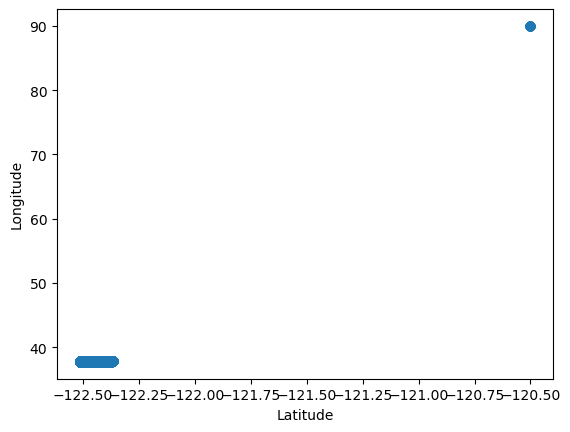

In [25]:
plt.scatter(x = dfTrain['X'], y = dfTrain['Y'], cmap = 'Set1')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

#### This shows some of the crime did not happen anywhere near San Francisco.  Must remove these outliers

In [26]:
dfTrain

,DayOfWeek,PdDistrict,Address,X,Y,Category
0,Wednesday,NORTHERN,OAK ST / LAGUNA ST,-122.425892,37.774599,WARRANTS
1,Wednesday,NORTHERN,OAK ST / LAGUNA ST,-122.425892,37.774599,OTHER OFFENSES
2,Wednesday,NORTHERN,VANNESS AV / GREENWICH ST,-122.424363,37.800414,OTHER OFFENSES
3,Wednesday,NORTHERN,1500 Block of LOMBARD ST,-122.426995,37.800873,LARCENY/THEFT
4,Wednesday,PARK,100 Block of BRODERICK ST,-122.438738,37.771541,LARCENY/THEFT
...,...,...,...,...,...,...
878044,Monday,TARAVAL,FARALLONES ST / CAPITOL AV,-122.459033,37.714056,ROBBERY
878045,Monday,INGLESIDE,600 Block of EDNA ST,-122.447364,37.731948,LARCENY/THEFT
878046,Monday,SOUTHERN,5TH ST / FOLSOM ST,-122.403390,37.780266,LARCENY/THEFT
878047,Monday,SOUTHERN,TOWNSEND ST / 2ND ST,-122.390531,37.780607,VANDALISM


#### Drop values for longitude (Y) that are not in/around San Francisco

In [28]:
dfTrain.drop(dfTrain[dfTrain['Y'] > 50].index, inplace=True)
dfTrain

,DayOfWeek,PdDistrict,Address,X,Y,Category
0,Wednesday,NORTHERN,OAK ST / LAGUNA ST,-122.425892,37.774599,WARRANTS
1,Wednesday,NORTHERN,OAK ST / LAGUNA ST,-122.425892,37.774599,OTHER OFFENSES
2,Wednesday,NORTHERN,VANNESS AV / GREENWICH ST,-122.424363,37.800414,OTHER OFFENSES
3,Wednesday,NORTHERN,1500 Block of LOMBARD ST,-122.426995,37.800873,LARCENY/THEFT
4,Wednesday,PARK,100 Block of BRODERICK ST,-122.438738,37.771541,LARCENY/THEFT
...,...,...,...,...,...,...
878044,Monday,TARAVAL,FARALLONES ST / CAPITOL AV,-122.459033,37.714056,ROBBERY
878045,Monday,INGLESIDE,600 Block of EDNA ST,-122.447364,37.731948,LARCENY/THEFT
878046,Monday,SOUTHERN,5TH ST / FOLSOM ST,-122.403390,37.780266,LARCENY/THEFT
878047,Monday,SOUTHERN,TOWNSEND ST / 2ND ST,-122.390531,37.780607,VANDALISM


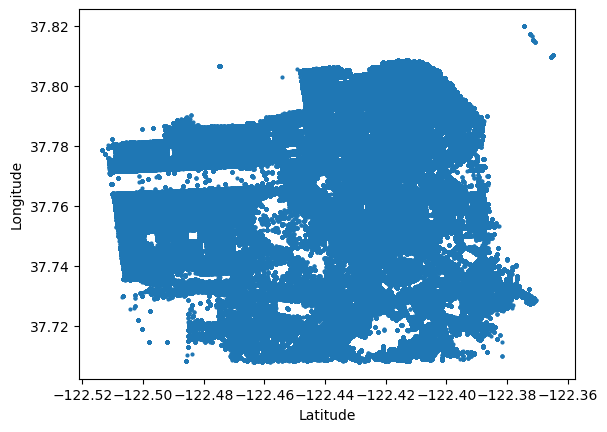

In [29]:
plt.scatter(x = dfTrain['X'], y = dfTrain['Y'], cmap = 'Set1', s = 4)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

#### See below for an outline of San Francisco...

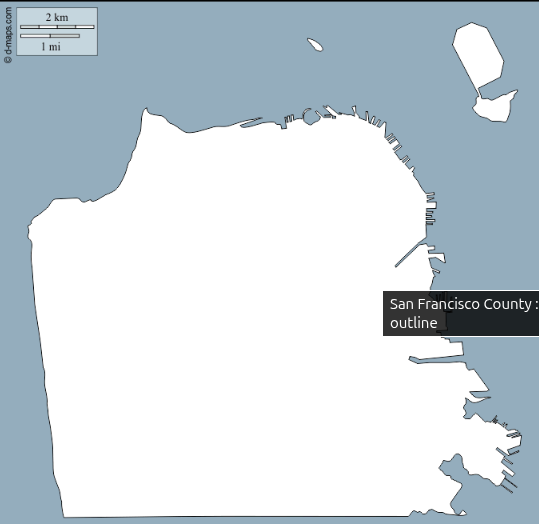

# SVM

In [30]:
# One-hot encoding of target variable
lblEnc = LabelEncoder()
dfTrain['Category'] = lblEnc.fit_transform(dfTrain['Category'])
X = dfTrain.drop(columns = ['Category', 'DayOfWeek', 'PdDistrict', 'Address'], axis = 1)
y = dfTrain['Category']

In [31]:
X

,X,Y
0,-122.425892,37.774599
1,-122.425892,37.774599
2,-122.424363,37.800414
3,-122.426995,37.800873
4,-122.438738,37.771541
...,...,...
878044,-122.459033,37.714056
878045,-122.447364,37.731948
878046,-122.403390,37.780266
878047,-122.390531,37.780607


In [32]:
y

0         37
1         21
2         21
3         16
4         16
          ..
878044    25
878045    16
878046    16
878047    35
878048    12
Name: Category, Length: 877982, dtype: int64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = 0.2, 
                                                    random_state = 42, 
                                                    stratify = y)

In [34]:
y_train

181333     1
321483    24
25939      1
26259     20
400690    20
          ..
110201    21
195300     1
329014     1
543420     1
861462    12
Name: Category, Length: 702385, dtype: int64

In [35]:
y_test

282489    16
179625    21
50971      1
68605      1
150620    16
          ..
425154    19
219788     4
685422    36
296073    16
397179    32
Name: Category, Length: 175597, dtype: int64

In [36]:
model = LinearSVC(max_iter = 1000)
model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [37]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.20129045484831745


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       303
           1       0.00      0.00      0.00     15374
           2       0.00      0.00      0.00        81
           3       0.00      0.00      0.00        58
           4       0.00      0.00      0.00      7351
           5       0.00      0.00      0.00       864
           6       0.00      0.00      0.00       454
           7       0.00      0.00      0.00     10794
           8       0.00      0.00      0.00       856
           9       0.00      0.00      0.00       233
          10       0.00      0.00      0.00        51
          11       0.00      0.00      0.00        98
          12       0.00      0.00      0.00      2122
          13       0.00      0.00      0.00      3336
          14       0.00      0.00      0.00        29
          15       0.00      0.00      0.00       468
          16       0.21      0.89      0.34     34977
          17       0.00    

In [39]:
y_pred.shape

(175597,)

In [40]:
y_test.shape

(175597,)

In [41]:
y_test

282489    16
179625    21
50971      1
68605      1
150620    16
          ..
425154    19
219788     4
685422    36
296073    16
397179    32
Name: Category, Length: 175597, dtype: int64

In [42]:
preds = model.predict(dfTest.drop(columns = ['Id']))
preds = lblEnc.inverse_transform(preds) # Un-encodes Category for readability
dfSub = pd.DataFrame()
dfSub['id'] = dfTest['Id']
dfSub['Category'] = preds
dfSub

,id,Category
0,0,LARCENY/THEFT
1,1,LARCENY/THEFT
2,2,LARCENY/THEFT
3,3,OTHER OFFENSES
4,4,OTHER OFFENSES
...,...,...
884257,884257,LARCENY/THEFT
884258,884258,LARCENY/THEFT
884259,884259,OTHER OFFENSES
884260,884260,LARCENY/THEFT


In [43]:
dfSub.to_csv("submissionSVM.csv", index = False)

In [44]:
print(os.getcwd())

/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 8


# Gradient boost

In [45]:
model = GradientBoostingRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 6,
    random_state = 42,
    loss = 'squared_error')
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


In [46]:
y_pred = model.predict(X_test)
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Training Accuracy: 0.018206646319652964
Testing Accuracy: 0.014769570486226957


In [47]:
preds = model.predict(dfTest.drop(columns = ['Id']))

In [48]:
preds

array([20.72077142, 19.69365865, 20.13827535, ..., 20.9508659 ,
       20.44936226, 19.45796789], shape=(884262,))

In [49]:
#preds = lblEnc.inverse_transform(preds)
dfSub = pd.DataFrame()
dfSub['id'] = dfTest['Id']
dfSub['Category'] = preds
dfSub

,id,Category
0,0,20.720771
1,1,19.693659
2,2,20.138275
3,3,20.900208
4,4,20.900208
...,...,...
884257,884257,20.375867
884258,884258,19.410423
884259,884259,20.950866
884260,884260,20.449362


##### I've had this problem before, where the Gradient Boosting Regressor did not predict in integer format, only float.  Creating submission anyway.

In [50]:
dfSub.to_csv("submissionGBR.csv", index = False)

# Decision tree classifier

In [51]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
y_pred = model.predict(X_test)
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training Accuracy: 0.3291271880806111
Testing Accuracy: 0.2792815367005131

Confusion Matrix:
 [[   6   63    0 ...   15    0    1]
 [   2 3651    0 ...  449   64    8]
 [   0    7    0 ...    2    0    0]
 ...
 [   9 1071    0 ... 1645   24   11]
 [   7  897    1 ...  154  114    2]
 [   0  405    0 ...   46    6    5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.07      0.02      0.03       303
           1       0.18      0.24      0.20     15374
           2       0.00      0.00      0.00        81
           3       0.00      0.00      0.00        58
           4       0.15      0.13      0.14      7351
           5       0.12      0.01      0.02       864
           6       0.02      0.00      0.00       454
           7       0.29      0.47      0.36     10794
           8       0.00      0.00      0.00       856
           9       0.00      0.00      0.00       233
          10       0.00      0.00      0.00        51
   

In [53]:
preds = model.predict(dfTest.drop(columns = ['Id']))
preds = lblEnc.inverse_transform(preds)
pdSub = pd.DataFrame({'id': dfTest['Id'], 'Category': preds})
pdSub

,id,Category
0,0,VANDALISM
1,1,OTHER OFFENSES
2,2,VEHICLE THEFT
3,3,ASSAULT
4,4,ASSAULT
...,...,...
884257,884257,BURGLARY
884258,884258,LARCENY/THEFT
884259,884259,OTHER OFFENSES
884260,884260,OTHER OFFENSES


In [54]:
pdSub.to_csv("submissionDTC.csv", index = False)
print(os.getcwd())

/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 8


In [55]:
model = BaggingClassifier()
model.fit(X_train, y_train)

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [56]:
y_pred = model.predict(X_test)
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training Accuracy: 0.3271795382874065
Testing Accuracy: 0.2779204656115993

Confusion Matrix:
 [[   2   55    0 ...   25    2    1]
 [   0 3279    0 ...  583  105   16]
 [   0    4    0 ...    2    0    1]
 ...
 [   5  807    0 ... 1993   71   14]
 [   2  805    0 ...  186  143    5]
 [   0  373    0 ...   57   16    7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.05      0.01      0.01       303
           1       0.18      0.21      0.20     15374
           2       0.00      0.00      0.00        81
           3       0.00      0.00      0.00        58
           4       0.16      0.10      0.12      7351
           5       0.13      0.02      0.04       864
           6       0.03      0.00      0.00       454
           7       0.30      0.47      0.36     10794
           8       0.09      0.00      0.01       856
           9       0.00      0.00      0.00       233
          10       0.00      0.00      0.00        51
   

#### The bagging classifier has accuracy results very similar to the decision tree classifier.

In [58]:
preds = model.predict(dfTest.drop(columns = ['Id']))
preds = lblEnc.inverse_transform(preds)
pdSub = pd.DataFrame({'id': dfTest['Id'], 'category': preds})
pdSub

,id,category
0,0,VEHICLE THEFT
1,1,OTHER OFFENSES
2,2,VEHICLE THEFT
3,3,ASSAULT
4,4,ASSAULT
...,...,...
884257,884257,BURGLARY
884258,884258,BURGLARY
884259,884259,OTHER OFFENSES
884260,884260,OTHER OFFENSES


In [59]:
pdSub.to_csv("submissionBagger.csv", index = False)

In [60]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
y_pred = model.predict(X_test)
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training Accuracy: 0.3291029848302569
Testing Accuracy: 0.2788145583352791

Confusion Matrix:
 [[   2   55    0 ...   22    3    1]
 [   0 3293    0 ...  579  109   18]
 [   0    4    0 ...    2    0    0]
 ...
 [   3  813    0 ... 2033   66   14]
 [   4  799    0 ...  194  160    5]
 [   0  368    0 ...   64   14   12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.06      0.01      0.01       303
           1       0.18      0.21      0.20     15374
           2       0.00      0.00      0.00        81
           3       0.00      0.00      0.00        58
           4       0.16      0.10      0.12      7351
           5       0.11      0.01      0.02       864
           6       0.00      0.00      0.00       454
           7       0.30      0.47      0.36     10794
           8       0.00      0.00      0.00       856
           9       0.00      0.00      0.00       233
          10       0.00      0.00      0.00        51
   

#### Once again, the random forest classifier has accuracy scores very similar to the previous two classifiers.

In [63]:
preds = model.predict(dfTest.drop(columns = ['Id']))
preds = lblEnc.inverse_transform(preds)
pdSub = pd.DataFrame({'id': dfTest['Id'], 'Category': preds})
pdSub

,id,Category
0,0,VANDALISM
1,1,OTHER OFFENSES
2,2,VEHICLE THEFT
3,3,ASSAULT
4,4,ASSAULT
...,...,...
884257,884257,VANDALISM
884258,884258,LARCENY/THEFT
884259,884259,VEHICLE THEFT
884260,884260,OTHER OFFENSES


In [64]:
pdSub.to_csv("submissionRF.csv", index = False)

### Note: all submissions for this competition to Kaggle.com gave an error:

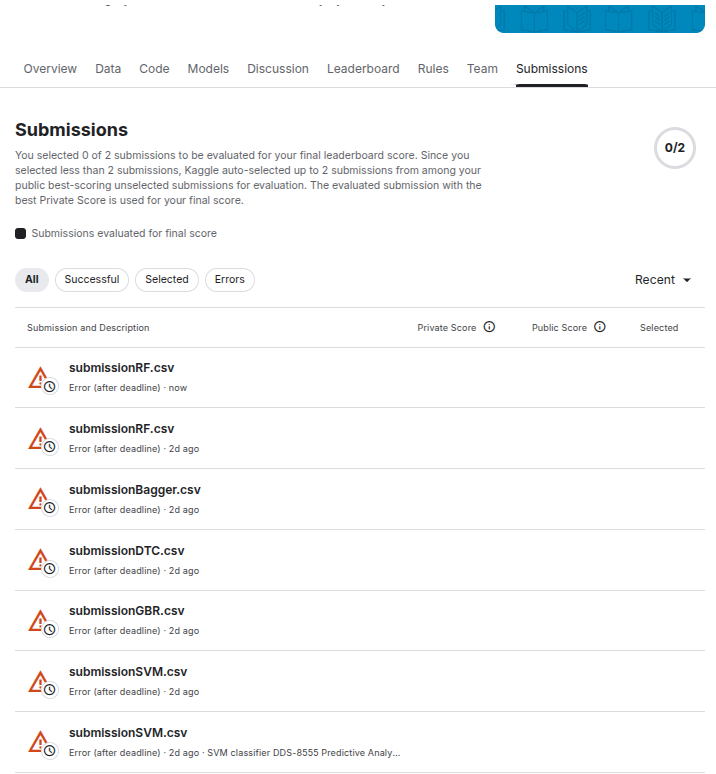